In [2]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

In [1]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from abm.model import SocialGPModel, as_batch_fixed
from abm.rewards import make_correlated_dog
from abm.utils import plot_reward_grid, animate_heatmap_trajectory

sns.set_theme(style="whitegrid")

# Dyadic simulations
This notebook explores different aspects of two agents interacting (on correlated Mexican hat rewards)

## 1. Explore two agents, human adult parameters
This section dives deeper into individual agents for single runs

### 1.a Homogeneous agents

In [72]:
grid_size   = 20
lambda_true = 3
# From literature: estimated human param vs true param in reward environment
naito_lambda_ratio   = 1.59 / 1.5  # from pair experiments
witt_VS_lambda_ratio = 2.42 / 2    # from group experiments 
witt_SG_lambda_ratio = 1.11 / 2    # from group experiments 

# Define reward parameters for the Mexican Hat GP environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 1.0
}

# NOTE: Mesa batch_run treats iterables as sweep dimensions.
# Wrap reporter lists in an outer list so they are passed as one fixed value.
reporters = ["global_max", "local_max", "reward"] #, "policy", "choice","value"]

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito_pair_VS': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": 0.1,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0.18,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'naito_SG': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "social_generalization",
        "beta": 0.3,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "sigma_social": 11,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'witt_VS': {
        "n": 3,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": 0.07,
        "length_scale": lambda_true*witt_VS_lambda_ratio,
        "tau": 0.09,
        "alpha": 0.12,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'witt_SG': {
        "n": 3,
        "grid_size": grid_size,
        "social_information_mode": "social_generalization",
        "beta": 0.33,
        "length_scale": lambda_true*witt_SG_lambda_ratio,
        "tau": 0.03,
        "sigma_social": 12.55,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'explorer_asocial': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": 0.675,
        "length_scale": lambda_true*0.555,
        "tau": 0.012,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'explorer_VS': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": 0.675,
        "length_scale": lambda_true*0.555,
        "tau": 0.012,
        "alpha": 0.12,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'explorer_SG': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "social_generalization",
        "beta": 0.675,
        "length_scale": lambda_true * 0.555,
        "tau": 0.012,
        "sigma_social": 12.55,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'exploiter_VS': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": 0.125,
        "length_scale": lambda_true * 0.555,
        "tau": 0.012,
        "alpha": 0.12,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'exploiter_SG': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "social_generalization",
        "beta": 0.125,
        "length_scale": lambda_true * 0.555,
        "tau": 0.012,
        "sigma_social": 12.55,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
}

In [73]:
n_envs         = 10
n_runs_per_env = 20
n_runs         = n_envs * n_runs_per_env
max_steps      = 150
param_set      = 'witt_SG' # 'optimal_cum_reward_20steps' # 'lambda_is_sigma_o_low_random'

# Create a master random number generator for reproducibility
master_rng = np.random.default_rng(1234)
env_seeds  = master_rng.integers(0, 2**63, size=n_envs, dtype=np.int64)
run_seeds  = master_rng.integers(0, 2**63, size=(n_runs_per_env), dtype=np.int64)

params[param_set]["env_seed"] = env_seeds.tolist()
params[param_set]["run_seed"] = run_seeds.flatten().tolist()

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params[param_set],  # Change this to run different conditions
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
N_AGENTS='3' \
MAX_STEPS='150' \
SOCIAL_INFORMATION_MODE='social_generalization' \
SIGMA_SOCIAL_BY_AGENT='12.55,12.55,12.55' \
BETA_BY_AGENT='0.125,0.125,0.675' \
TAU_BY_AGENT='0.012,0.012,0.012' \
LENGTH_SCALE_MULTIPLIERS_BY_AGENT='0.555,0.555,0.555' \
sbatch --export=ALL,OUTPUT_DIR=/scratch/parra/20260716_triad --job-name=exploit_exploit_explore_SG /home/parra/Spatial-MAB-taboo/run_single_job.sh

N_AGENTS='2' \
MAX_STEPS='150' \
ALPHA_BY_AGENT='0.12,0.12' \
BETA_BY_AGENT='0.675,0.07' \
TAU_BY_AGENT='0.012,0.09' \
LENGTH_SCALE_MULTIPLIERS_BY_AGENT='0.555,1.21' \
sbatch --export=ALL,OUTPUT_DIR=/scratch/parra/dyadic250_0715 --job-name=explore_Witt_VS /home/parra/Spatial-MAB-taboo/run_single_job.sh

In [81]:
# df_batch = pd.DataFrame(batch_results)
# df_batch.to_csv('/scratch/parra/20260716_triad/witt_SG_homo.csv')
df_batch = pd.read_csv('/scratch/parra/dyadic250_0715/explore_Witt_VS.csv')
# df_batch = pd.read_csv('/scratch/parra/20260716_triad/witt_VS_homo.csv')

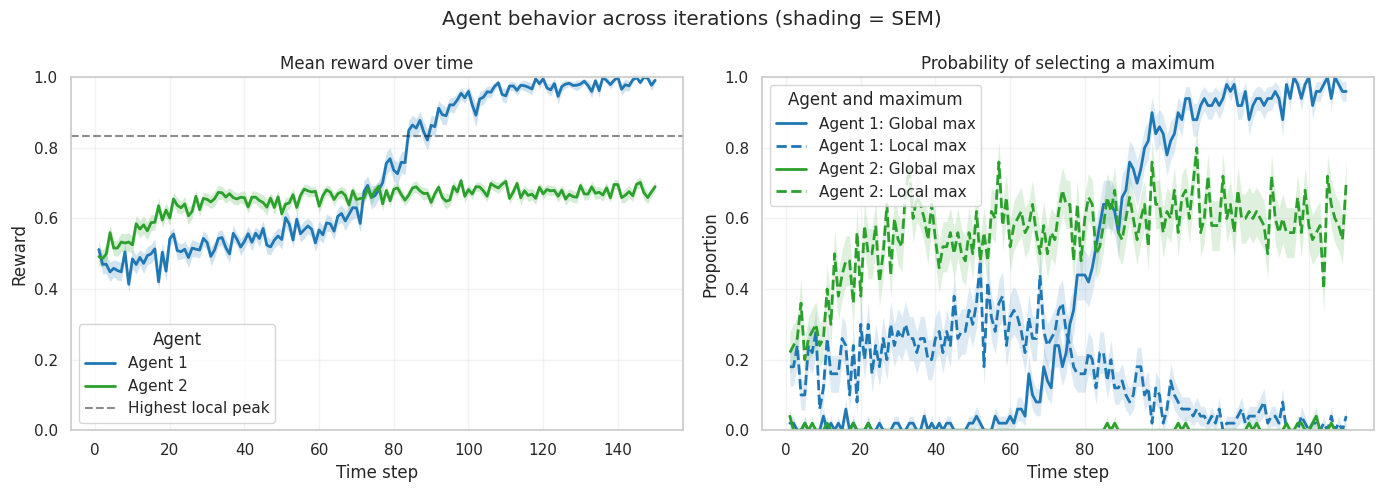

In [82]:
# Choose "std" for standard deviation or "sem" for standard error of the mean.
error_type = "sem"
# control the color assigned to each AgentID.
agent_colors = {
    1: "tab:blue",
    2: "tab:green",
    3: "tab:orange"
}
agent_labels = {
    1: 'Agent 1',
    2: 'Agent 2',
    3: 'Agent 3'
}

# Aggregate separately by time step and agent.
df_grouped = (
    df_batch
    .groupby(["AgentID", "Step"], as_index=False)
    .agg(
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        reward_count=("reward", "count"),
        global_max_mean=("global_max", "mean"),
        global_max_std=("global_max", "std"),
        global_max_count=("global_max", "count"),
        local_max_mean=("local_max", "mean"),
        local_max_std=("local_max", "std"),
        local_max_count=("local_max", "count"),
    )
)

# Replace undefined standard deviations (groups containing one row) with zero.
std_columns = [
    "reward_std",
    "global_max_std",
    "local_max_std",
]
df_grouped[std_columns] = df_grouped[std_columns].fillna(0)

# Select the uncertainty shown by the shaded areas.
for metric in ["reward", "global_max", "local_max"]:
    if error_type == "sem":
        df_grouped[f"{metric}_error"] = (
            df_grouped[f"{metric}_std"]
            / np.sqrt(df_grouped[f"{metric}_count"])
        )
    elif error_type == "std":
        df_grouped[f"{metric}_error"] = df_grouped[f"{metric}_std"]
    else:
        raise ValueError("error_type must be 'std' or 'sem'")

agent_ids = sorted(df_grouped["AgentID"].unique())

# Assign fallback colors if an AgentID is missing from agent_colors.
fallback_colors = plt.get_cmap("tab10").colors
for index, agent_id in enumerate(agent_ids):
    agent_colors.setdefault(agent_id, fallback_colors[index % len(fallback_colors)])

fig, (ax_reward, ax_maxima) = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
)

for agent_id in agent_ids:
    agent_data = (
        df_grouped[df_grouped["AgentID"] == agent_id]
        .sort_values("Step")
    )

    step = agent_data["Step"].to_numpy()
    color = agent_colors[agent_id]

    # Left subplot: reward
    reward_mean = agent_data["reward_mean"].to_numpy()
    reward_error = agent_data["reward_error"].to_numpy()

    ax_reward.plot(
        step,
        reward_mean,
        color=color,
        linewidth=2,
        label=agent_labels[agent_id],
    )
    ax_reward.fill_between(
        step,
        reward_mean - reward_error,
        reward_mean + reward_error,
        color=color,
        alpha=0.20,
        linewidth=0,
    )

    # Right subplot: global and local maximum probabilities/rates
    for metric, label, linestyle in [
        ("global_max", "Global max", "-"),
        ("local_max", "Local max", "--"),
    ]:
        mean = agent_data[f"{metric}_mean"].to_numpy()
        error = agent_data[f"{metric}_error"].to_numpy()

        ax_maxima.plot(
            step,
            mean,
            color=color,
            linestyle=linestyle,
            linewidth=2,
            label=f"{agent_labels[agent_id]}: {label}",
        )
        ax_maxima.fill_between(
            step,
            np.clip(mean - error, 0, 1),
            np.clip(mean + error, 0, 1),
            color=color,
            alpha=0.15,
            linewidth=0,
        )

ax_reward.axhline(y=1/1.2, color='k', linestyle='--', alpha=0.5, label='Highest local peak')
ax_reward.set(
    title="Mean reward over time",
    xlabel="Time step",
    ylabel="Reward",
    ylim=(0, 1),
)
ax_reward.legend(title="Agent")
ax_reward.grid(alpha=0.25)

ax_maxima.set(
    title="Probability of selecting a maximum",
    xlabel="Time step",
    ylabel="Proportion",
    ylim=(0, 1),
)
ax_maxima.legend(title="Agent and maximum")
ax_maxima.grid(alpha=0.25)

fig.suptitle(f"Agent behavior across iterations (shading = {error_type.upper()})")
fig.tight_layout()
plt.show()

In [ ]:
# Use animate_heatmap_trajectory to plot value evolution for each focal agent
for focal_agent in [1]:#sorted(df_batch['AgentID'].unique()):
    animate_heatmap_trajectory(
        df_batch,
        heatmap_col='value',
        choice_col='choice',
        focal_agent=focal_agent,
        agent_id_col='AgentID',
        step_col='Step',
        fps=1,
        save_path=f'agent_{focal_agent}_value_trajectory.gif',
    )

KeyError: "Column 'value' not found in dataframe."

### 1.b Heterogeneous agents

In [19]:
grid_size   = 33
lambda_true = 4.5
# From literature: ratio of estimated human parameter to true lambda in the reward function
naito_lambda_ratio = 1.59 / 1.5
wittVS_lambda_ratio = 2.45 / 2
giron58_lambda_ratio = 0.43/4

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 1.0
}

# NOTE: Mesa batch_run treats iterables as sweep dimensions.
# Wrap reporter lists in an outer list so they are passed as one fixed value.
reporters = ["global_max", "local_max", "reward", "policy", "choice","value"]

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito_pair': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": 0.1,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0.18,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'witt_VS': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": 0.07,
        "length_scale": lambda_true*wittVS_lambda_ratio,
        "tau": 0.09,
        "alpha": 0.12,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'giron_5-8': {
        "n": 1,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": 0.53,
        "length_scale": lambda_true*giron58_lambda_ratio,
        "tau": 0.02,
        "alpha": 0.12,  # No VS in Giron, from Witt
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'WittVS_Giron5-8_hetero': {
        "n": 2,
        "grid_size": grid_size,
        "social_information_mode": "value_shaping",
        "beta": as_batch_fixed([0.07, 0.53]),
        "length_scale": as_batch_fixed([lambda_true*wittVS_lambda_ratio, lambda_true*giron58_lambda_ratio]),
        "tau": as_batch_fixed([0.09, 0.02]),
        "alpha": as_batch_fixed([0.12, 0.12]),  # No VS in Giron, from Witt
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    }
}

In [5]:
rng       = np.random.default_rng(42)
max_steps = 30

batch_results = mesa.batch_run(
    SocialGPModel,
    rng=rng,
    parameters=params['WittVS_Giron5-8_hetero'],
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/1 [00:00<?, ?it/s]

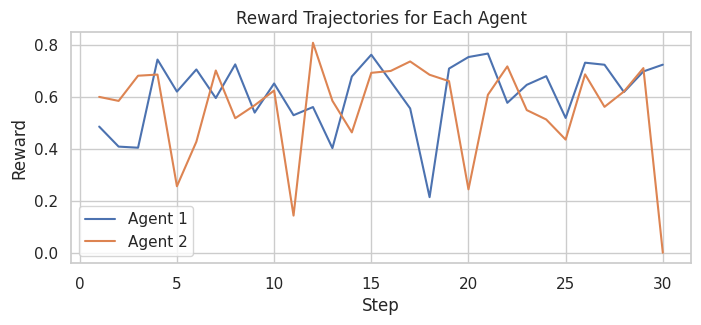

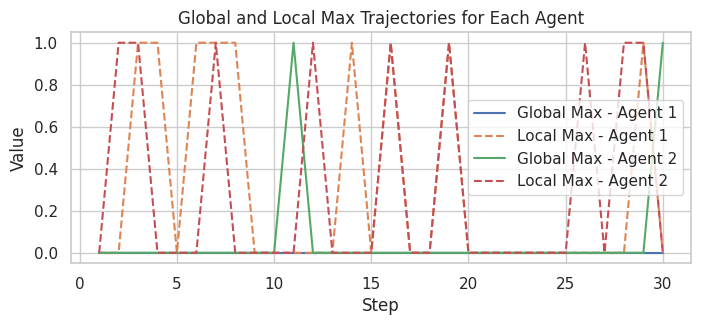

In [7]:
df_batch = pd.DataFrame(batch_results)

# Plot reward trajectories for each agent
plt.figure(figsize=(8, 3))
for agent_id in df_batch['AgentID'].unique():
    agent_data = df_batch[df_batch['AgentID'] == agent_id]
    plt.plot(agent_data['Step'], agent_data['reward'], label=f'Agent {agent_id}')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward Trajectories for Each Agent')
plt.legend()
plt.show()

# Plot global and local max trajectories for each agent
plt.figure(figsize=(8, 3))
for agent_id in df_batch['AgentID'].unique():
    agent_data = df_batch[df_batch['AgentID'] == agent_id]
    plt.plot(agent_data['Step'], agent_data['global_max'], label=f'Global Max - Agent {agent_id}', linestyle='-')
    plt.plot(agent_data['Step'], agent_data['local_max'], label=f'Local Max - Agent {agent_id}', linestyle='--')
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Global and Local Max Trajectories for Each Agent')
plt.legend()
plt.show()

## 2. Dyadic batches
This section runs larger batches to examine average behavior

## Value Shaping dyad
BETA_BY_AGENT='0.125,0.675' TAU_BY_AGENT='0.012,0.012' ALPHA_BY_AGENT='0.12,0.12' LENGTH_SCALE_MULTIPLIERS_BY_AGENT='1.0,0.5' SOCIAL_INFORMATION_MODE='value_shaping' sbatch --export=ALL,OUTPUT_DIR=/scratch/parra/dyadic500 run_single_job.sh

## Social Generalization dyad (use as_batch_fixed([12.55, 12.55]) for sigma_social vectors in mesa.batch_run)
SOCIAL_INFORMATION_MODE='social_generalization' SIGMA_SOCIAL_BY_AGENT='12.55, 3' BETA_BY_AGENT='0.33,0.125' TAU_BY_AGENT='0.012,0.012' LENGTH_SCALE_MULTIPLIERS_BY_AGENT='0.555' sbatch --export=ALL,OUTPUT_DIR=/scratch/parra/dyadic500 run_single_job.sh

In [26]:
# load /scratch/[batch]/parameter_sweep.csv 
df_batch = pd.read_csv('/scratch/parra/dyadic500/mab-dyadic-hetero-optimal-peak-exploit.csv')

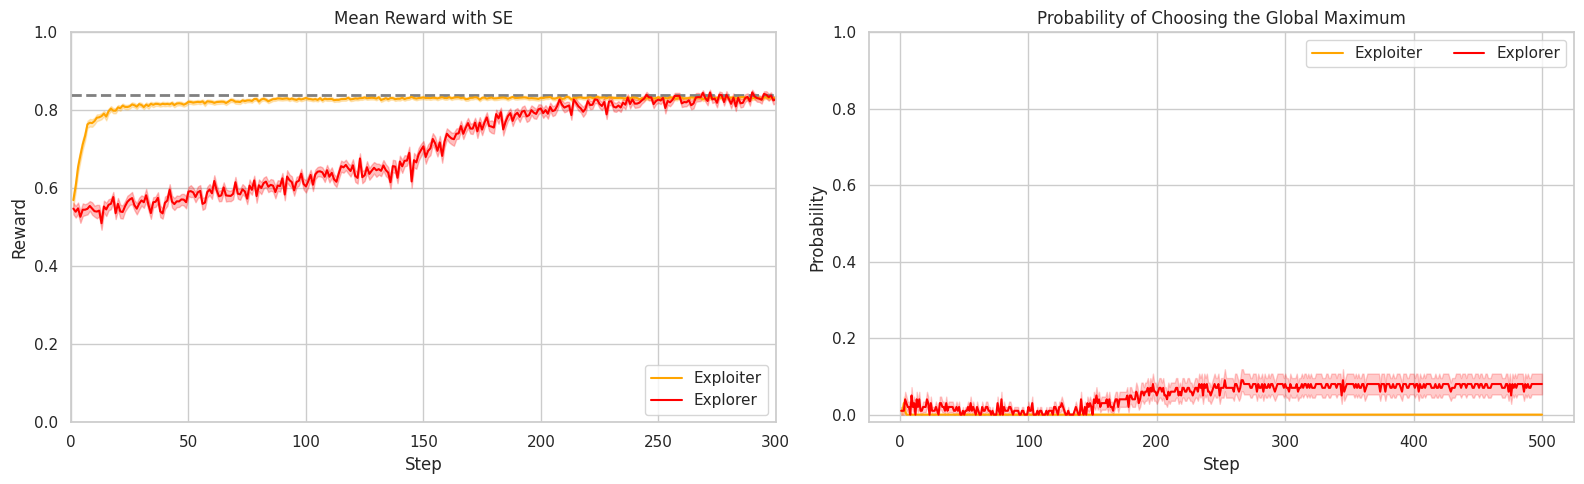

In [28]:
# Aggregate combined sweep output by step and agent
required_cols = ['Step', 'AgentID', 'reward', 'global_max', 'local_max']
missing_cols = [col for col in required_cols if col not in df_batch.columns]
if missing_cols:
    raise KeyError(f"df_batch is missing required columns: {missing_cols}")

df_plot = df_batch[required_cols].copy()

# Ensure numeric columns are numeric
for col in ['reward', 'global_max', 'local_max']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

df_grouped = (
    df_plot.groupby(['Step', 'AgentID'], as_index=False)
    .agg(
        reward_mean=('reward', 'mean'),
        reward_std=('reward', 'std'),
        reward_n=('reward', 'count'),
        global_max_mean=('global_max', 'mean'),
        global_max_std=('global_max', 'std'),
        global_max_n=('global_max', 'count'),
        local_max_mean=('local_max', 'mean'),
        local_max_std=('local_max', 'std'),
        local_max_n=('local_max', 'count'),
    )
)

# Plot mean reward and probabilities in adjacent subplots, one line per agent
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

agent_ids = sorted(df_grouped['AgentID'].unique())
colors = ['orange', 'red'] # plt.cm.tab10(np.linspace(0, 1, len(agent_ids)))
agents = ['Exploiter', 'Explorer']


axes[0].hlines(y=0.84, xmin=0, xmax=300, color='gray', linestyle='--', linewidth=2)

for color, agent_id in zip(colors, agent_ids):
    agent_df = df_grouped[df_grouped['AgentID'] == agent_id].sort_values('Step')

    reward_se = (agent_df['reward_std'] / np.sqrt(agent_df['reward_n'].clip(lower=1))).fillna(0.0)
    global_max_se = (agent_df['global_max_std'] / np.sqrt(agent_df['global_max_n'].clip(lower=1))).fillna(0.0)
    local_max_se = (agent_df['local_max_std'] / np.sqrt(agent_df['local_max_n'].clip(lower=1))).fillna(0.0)

    # Left: mean reward
    axes[0].plot(agent_df['Step'], agent_df['reward_mean'], label=agents[agent_id-1], color=color)
    axes[0].fill_between(
        agent_df['Step'],
        agent_df['reward_mean'] - reward_se,
        agent_df['reward_mean'] + reward_se,
        alpha=0.25,
        color=color,
    )

    # Right: probabilities (solid=global, dashed=local)
    axes[1].plot(
        agent_df['Step'],
        agent_df['global_max_mean'],
        label=agents[agent_id-1], #f'Agent {int(agent_id)} global',
        color=color,
        linestyle='-',
    )
    axes[1].fill_between(
        agent_df['Step'],
        agent_df['global_max_mean'] - global_max_se,
        agent_df['global_max_mean'] + global_max_se,
        alpha=0.20,
        color=color,
    )

    # axes[1].plot(
    #     agent_df['Step'],
    #     agent_df['local_max_mean'],
    #     label=f'Agent {int(agent_id)} local',
    #     color=color,
    #     linestyle='--',
    # )
    # axes[1].fill_between(
    #     agent_df['Step'],
    #     agent_df['local_max_mean'] - local_max_se,
    #     agent_df['local_max_mean'] + local_max_se,
    #     alpha=0.20,
    #     color=color,
    # )

axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')

axes[0].set_xlim(0, 300)

axes[1].set_title('Probability of Choosing the Global Maximum')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(-0.02, 1)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()